# Clustering and marker genes

This notebook performs dimensionality reduction, clustering, and marker gene identification on preprocessed single-cell data.

In [3]:
from pathlib import Path

import scanpy as sc
import matplotlib.pyplot as plt

## Load data

In [4]:
adata = sc.read("../data/processed/adata_qc.h5ad")
adata

AnnData object with n_obs × n_vars = 2638 × 13656
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells'
    uns: 'log1p'

In [7]:
print(adata.shape)
adata.var.head()

(2638, 13656)


,gene_ids,mt,n_cells_by_counts,mean_counts,pct_dropout_by_counts,total_counts,n_cells
index,,,,,,,
AL627309.1,ENSG00000237683,False,9,0.003333,99.666667,9.0,9
AP006222.2,ENSG00000228463,False,3,0.001111,99.888889,3.0,3
RP11-206L10.2,ENSG00000228327,False,5,0.001852,99.814815,5.0,5
RP11-206L10.9,ENSG00000237491,False,3,0.001111,99.888889,3.0,3
LINC00115,ENSG00000225880,False,18,0.006667,99.333333,18.0,18


## Select HVG

I want to remove genes that are expressed everywhere, or barely expressed. 

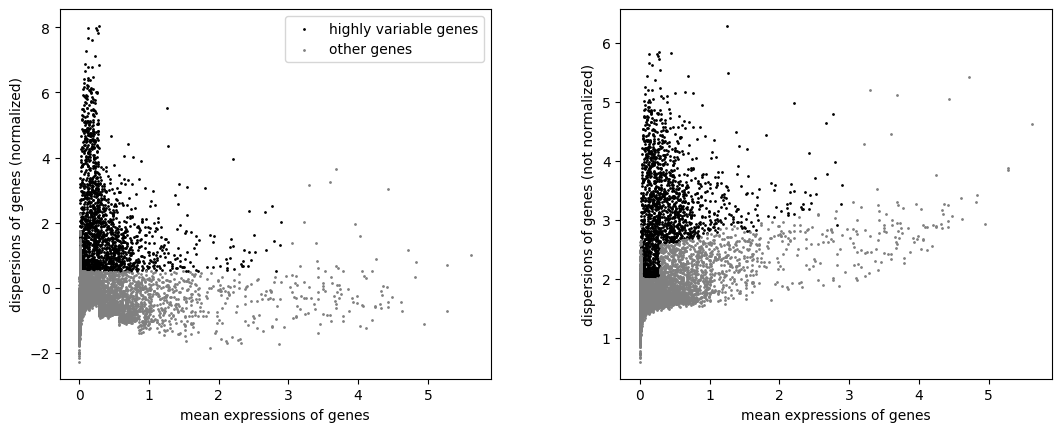

In [10]:
sc.pp.highly_variable_genes(
    adata,
    min_mean=0.0125,
    max_mean=3,
    min_disp=0.5
)

sc.pl.highly_variable_genes(adata)

This should store information on adata.var["highly_variable"] as boolean. Can also be accessed using adata.var.highly_variable

In [ ]:
adata.var.highly_variable

index
TNFRSF4    True
CPSF3L     True
ATAD3C     True
C1orf86    True
RER1       True
           ... 
ICOSLG     True
SUMO3      True
SLC19A1    True
S100B      True
PRMT2      True
Name: highly_variable, Length: 1826, dtype: bool

I'll subset the data to only select HVG

In [11]:
adata = adata[:,adata.var.highly_variable]
adata

View of AnnData object with n_obs × n_vars = 2638 × 1826
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt'
    var: 'gene_ids', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

No we are only analysing 2000 genes (compared to 30,000 in raw)

## Normalising Data

In [14]:
sc.pp.scale(adata,max_value=10)

/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/preprocessing/_scale.py:318: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


## Dimension reductionality

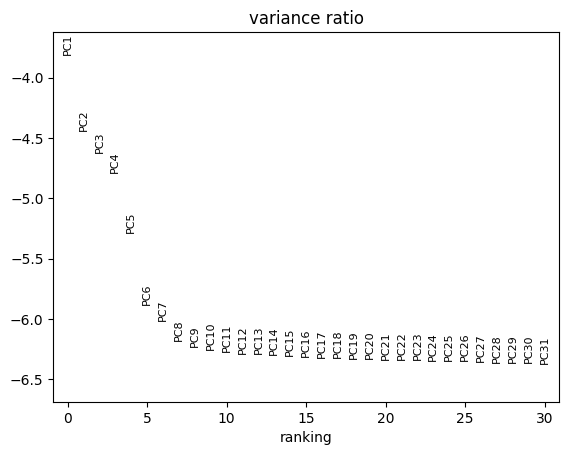

In [15]:
sc.tl.pca(adata, svd_solver="arpack")

sc.pl.pca_variance_ratio(adata,log=True)

Seems like most variation captured within first 7 dimensions. Im going to proceed with neigbouring the cells and visualise it.

In [ ]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata)

Seems like there are distinct separations here. Let's proceed with Leiden clustering.

/var/folders/3_/pdsgzgb17hg6fszr5spc0gz80000gq/T/ipykernel_74002/3720264198.py:1: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata)


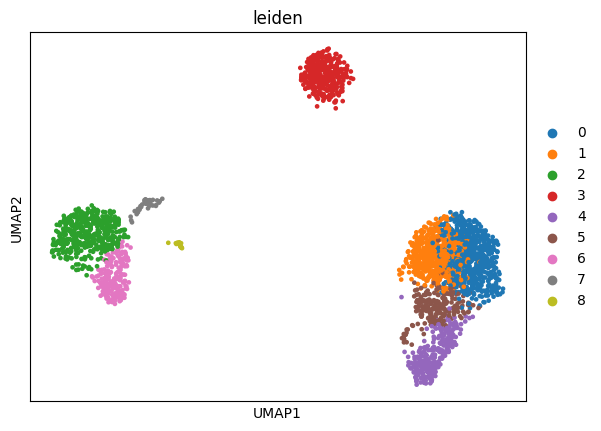

In [18]:
sc.tl.leiden(adata)

sc.pl.umap(adata,color=["leiden"]) #same graph as before but labelled

In [19]:
adata.write("../data/processed/adata_clustered.h5ad")

## Compute marker genes

I want to check what genes define each cluster

/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/tools/_rank_genes_groups.py:461: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/Users/zz6/projects/personal/single-cell-clu

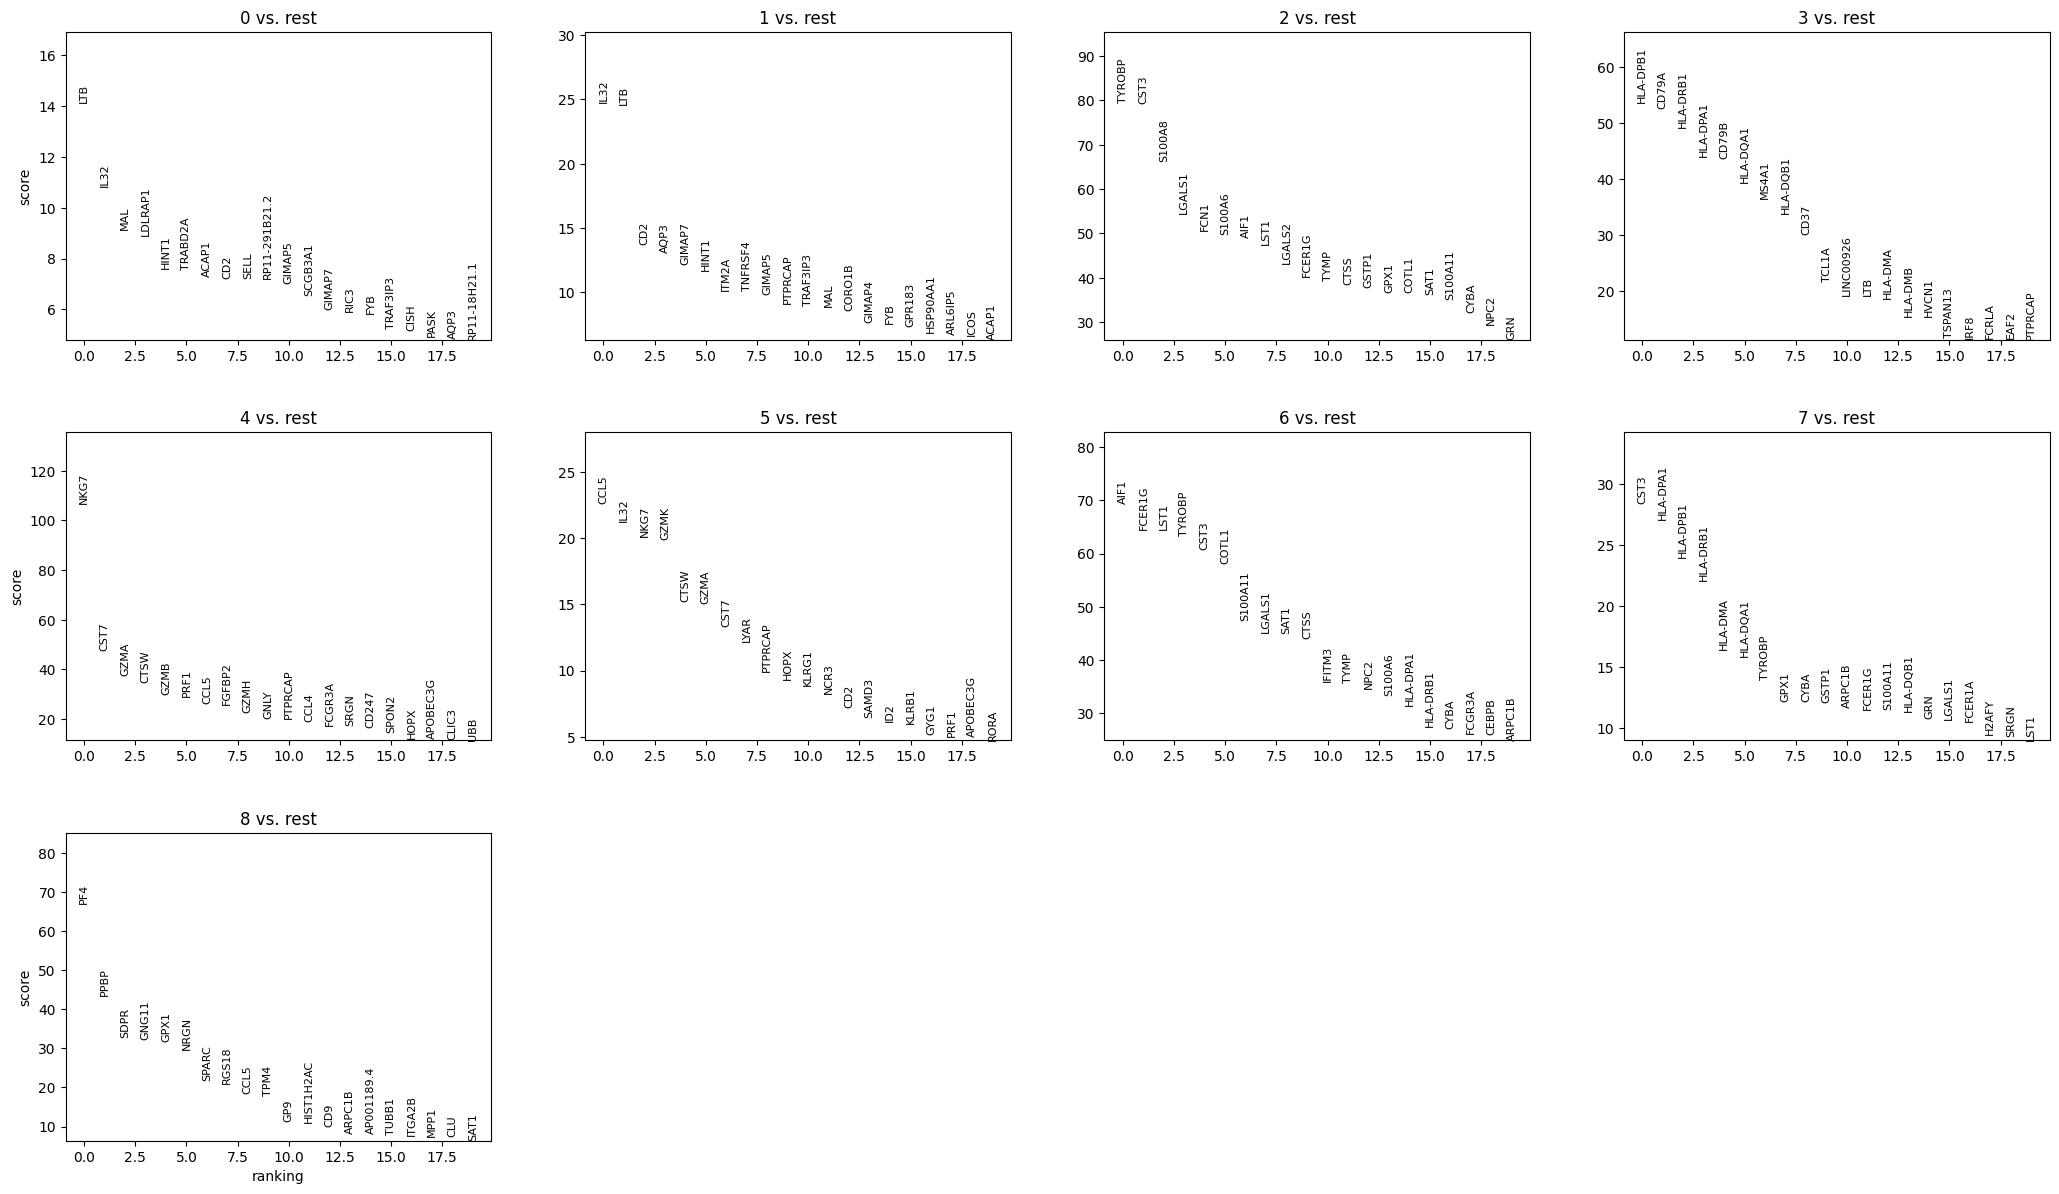

In [20]:
sc.tl.rank_genes_groups(adata, "leiden", method="t-test")

sc.pl.rank_genes_groups(adata, n_genes=20, sharey=False)

The graphs shows top 20 HVG genes compared to other cluters. Let's inspect the first 5 genes of one of the clusters.

/Users/zz6/projects/personal/single-cell-clustering-analysis/.venv/lib/python3.9/site-packages/scanpy/plotting/_tools/__init__.py:1320: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  _ax.set_xticklabels(new_gene_names, rotation="vertical")


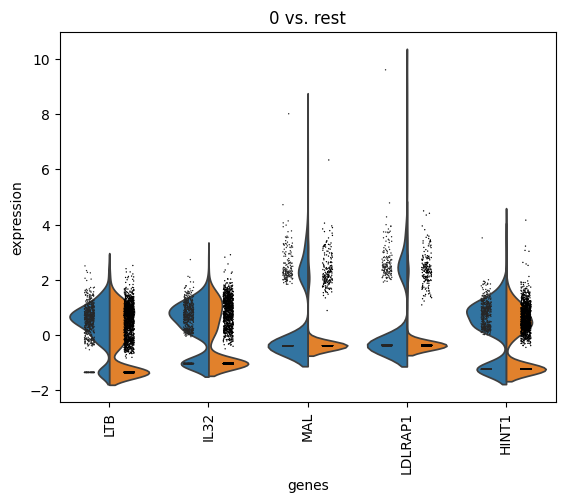

In [21]:
sc.pl.rank_genes_groups_violin(adata, groups="0", n_genes=5)

## Save object

Like before any functions we execute using scanpy create new columns in the object. We want to save this object for interpretation.

In [22]:
adata.write("../data/processed/adata_clustered.h5ad")